In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline
from tqdm import tqdm


# Load the skill extraction model
print("Loading skill extraction model...")
skill_extractor = pipeline(
    "token-classification",
    model="GalalEwida/LLM-BERT-Model-Based-Skills-Extraction-from-jobdescription",
    aggregation_strategy="simple"
)
print("✓ Model loaded")



Loading skill extraction model...


config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

✓ Model loaded


In [2]:
df = pd.read_csv('/kaggle/input/datasets/wissemweslati0/final-update/linkedin_jobs_with_auto_categories (4).csv')
print(f"Loaded {len(df)} jobs")

Loaded 1075 jobs


In [3]:
# ============================================================
# Add this BEFORE Cell 3 (skill extraction)
# ============================================================

import re

def extract_relevant_section(text):
    """
    Remove company introduction and extract only relevant parts:
    missions, responsibilities, qualifications
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Keywords that mark START of relevant content (French & English)
    start_keywords = [
        r'vos challenges',
        r'votre mission',
        r'description du poste',
        r'missions principales',
        r'vos missions',
        r'responsabilités',
        r'responsabilites',
        r'about the role',
        r'what you.?ll do',
        r'responsibilities',
        r'job description',
        r'your missions',
        r'key responsibilities',
        r'votre profil',
        r'your profile',
        r'qualifications',
        r'requirements',
        r'profil recherché',
        r'profil recherche',
        r'compétences',
        r'competences',
        r'what we.?re looking for',
        r'what you.?ll bring',
        r'required skills',
        r'your responsibilities',
    ]

    text_lower = text.lower()
    start_idx = len(text)

    # Find the earliest matching keyword
    for keyword in start_keywords:
        match = re.search(keyword, text_lower)
        if match:
            start_idx = min(start_idx, match.start())

    # If no keyword found, return full text
    if start_idx == len(text):
        return text

    # Return text from relevant section onwards
    return text[start_idx:]

# Apply the function
print("Removing company introductions...")
df['relevant_section'] = df['description'].apply(extract_relevant_section)
print(f"✓ Extracted relevant sections")



Removing company introductions...
✓ Extracted relevant sections


In [4]:
def extract_unique_skills(text):
    """Extract skills from text and remove redundancy"""

    if pd.isna(text) or len(str(text)) < 50:
        return []

    # Limit text length for model (max 512 tokens)
    text = str(text)[:3000]

    try:
        ents = skill_extractor(text)

        unique_skills = []
        seen = set()

        for e in ents:
            skill = e["word"].strip()
            skill_lower = skill.lower()

            # Skip empty or very short
            if len(skill) < 2:
                continue

            # Skip if exact duplicate (case-insensitive)
            if skill_lower in seen:
                continue

            # Skip if substring of existing skill
            is_redundant = False
            for existing in unique_skills:
                existing_lower = existing.lower()

                # Current skill is substring of existing
                if skill_lower in existing_lower and skill_lower != existing_lower:
                    is_redundant = True
                    break

            if is_redundant:
                continue

            # Remove existing skills that are substrings of current
            unique_skills = [
                s for s in unique_skills
                if not (s.lower() in skill_lower and s.lower() != skill_lower)
            ]

            unique_skills.append(skill)
            seen.add(skill_lower)

        return unique_skills

    except Exception as e:
        print(f"Error extracting skills: {e}")
        return []

In [5]:
print("\nExtracting skills from job descriptions...")
print("This may take a few minutes...")

# Add progress bar
tqdm.pandas()

# Extract skills (using relevant_section if available, else description)

df['extracted_skills_list'] = df['relevant_section'].progress_apply(extract_unique_skills)


# Convert list to comma-separated string for easier viewing
df['extracted_skills'] = df['extracted_skills_list'].apply(
    lambda x: ', '.join(x) if x else ''
)

# Count number of skills per job
df['num_skills'] = df['extracted_skills_list'].apply(len)

print(f"\n✓ Skill extraction complete!")
print(f"Jobs with skills extracted: {(df['num_skills'] > 0).sum()}/{len(df)}")
print(f"Average skills per job: {df['num_skills'].mean():.1f}")

# Show sample
print("\nSample extracted skills:")
sample = df[df['num_skills'] > 0][['title', 'final_category', 'extracted_skills']].head(5)
for idx, row in sample.iterrows():
    print(f"\n{row['title']} ({row['final_category']}):")
    print(f"  Skills: {row['extracted_skills']}")


Extracting skills from job descriptions...
This may take a few minutes...


100%|██████████| 1075/1075 [04:32<00:00,  3.94it/s]


✓ Skill extraction complete!
Jobs with skills extracted: 869/1075
Average skills per job: 7.0

Sample extracted skills:

BI / Data Engineer (Software Engineering):
  Skills: analytics, specifications, etl, dashboards, tests, sql

Data engineer (Software Engineering):
  Skills: reporting, log, data engineering

Data Engineer (Software Engineering):
  Skills: ##se, ka, java, dataset, sql, spring boot, scala, micro, cd, git

Data Engineer [F/M/X] (Software Engineering):
  Skills: data engineering, agile environment, data pipelines, azure, etl, analytics, data processing, ##apse, data ingestion, datasets, dashboards, reporting, feature engineering, machine learning, sql, spark, python, performance tuning, scrum, devops, cd, data science, ##se, optimization, integration

Data Analyst (Data & Business Analysis):
  Skills: statistical, modeling, unstructured, datasets, technical requirements, data management, data visualization, dashboards, orthopedics


In [6]:
df.to_csv('linkedin_jobs_with_extracted_skills_per_job.csv', index=False)
print(f"\n✓ Saved to 'linkedin_jobs_with_extracted_skills_per_job.csv'")


✓ Saved to 'linkedin_jobs_with_extracted_skills_per_job.csv'


In [7]:
NOISE_WORDS = {
    # Generic business terms
    'reporting', 'administration', 'planning', 'optimization',
    'methodology', 'specifications', 'information systems', 'sourcing',
    'forecasting', 'budgeting', 'forecasts', 'variance', 'operational support',
    'case management', 'quality', 'risk', 'screening', 'log', 'logs','##iti',' after','software', 'automation',

    # Too generic technical terms
    'software', 'technology', 'application', 'production', 'data',
    'integration', 'tests', 'testing', 'informati',

    # Job titles/roles (will be filtered based on your categories)
    'computer science', 'computer engineering', 'software development',
    'product management', 'business analysis', 'technical support',
    'application support', 'it operations', 'risk analysis',
    'data collection', 'data analysis', 'data management', 'data engineering',
    'data visualization', 'data science', 'financial analysis',
    'technology transformation','dynamics', 'automotive','##se'


}

def clean_and_merge_skills(skill_counts):

    cleaned = Counter()

    for skill, count in skill_counts.items():
        skill_lower = skill.lower().strip()

        # Skip noise words
        if skill_lower in NOISE_WORDS:
            continue

        # Merge CI/CD variations
        if skill_lower in ['ci', 'cd', 'ci cd', 'cicd']:
            cleaned['ci/cd'] += count
            continue
        cleaned[skill] = count

    return cleaned

In [8]:
print("\n" + "="*70)
print("AGGREGATING SKILLS BY DOMAIN (WITH CLEANING)")
print("="*70)

# Filter to categories with 10+ jobs
category_counts = df['final_category'].value_counts()
valid_categories = category_counts[category_counts >= 10].index.tolist()
if 'Other' in valid_categories:
    valid_categories.remove('Other')

df_filtered = df[df['final_category'].isin(valid_categories)].copy()

# Collect all skills per category
category_skills = {}

for category in valid_categories:
    category_jobs = df_filtered[df_filtered['final_category'] == category]

    # Collect all skills from all jobs in this category
    all_skills = []
    for skills_list in category_jobs['extracted_skills_list']:
        all_skills.extend(skills_list)

    # Count skill frequency
    skill_counts = Counter(all_skills)

    # CLEAN THE SKILLS HERE
    skill_counts = clean_and_merge_skills(skill_counts)

    # Store top 20 skills
    category_skills[category] = skill_counts.most_common(20)

    print(f"\n{category} ({len(category_jobs)} jobs):")
    print(f"  Total skills extracted: {len(all_skills)}")
    print(f"  Unique skills (after cleaning): {len(skill_counts)}")
    print(f"  Top 10: {', '.join([s for s, c in skill_counts.most_common(10)])}")


AGGREGATING SKILLS BY DOMAIN (WITH CLEANING)

Software Engineering (195 jobs):
  Total skills extracted: 2924
  Unique skills (after cleaning): 343
  Top 10: ci/cd, docker, python, devops, security, kubernetes, ai, algorithms, git, rest

Developer Développeur (166 jobs):
  Total skills extracted: 1387
  Unique skills (after cleaning): 260
  Top 10: ci/cd, python, angular, rest, devops, git, aws, java, jira, kubernetes

Ingénieur Technicien (120 jobs):
  Total skills extracted: 500
  Unique skills (after cleaning): 113
  Top 10: devops, linux, ai, python, azure, ci/cd, troubleshooting, aws, docker, saas

Manager Management (91 jobs):
  Total skills extracted: 411
  Unique skills (after cleaning): 95
  Top 10: ci/cd, jira, crm, scrum, scalability, data entry, devops, contingency, sdlc, software services

IT Consulting & ERP (74 jobs):
  Total skills extracted: 337
  Unique skills (after cleaning): 101
  Top 10: saas, dashboards, troubleshooting, crm, acceptance, sql, spark, data integri

In [9]:
summary_data = []

for category, skills in category_skills.items():
    num_jobs = len(df_filtered[df_filtered['final_category'] == category])

    top_10 = [s for s, c in skills[:10]]
    top_20 = [s for s, c in skills[:20]]

    summary_data.append({
        'domain': category,
        'num_jobs': num_jobs,
        'unique_skills': len(skills),
        'top_10_skills': ', '.join(top_10),
        'top_20_skills': ', '.join(top_20)
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('num_jobs', ascending=False)

print("\n" + "="*70)
print("SKILLS SUMMARY BY DOMAIN")
print("="*70)
print(summary_df[['domain', 'num_jobs', 'unique_skills', 'top_10_skills']])

summary_df.to_csv('skills_by_domain_summary.csv', index=False)
print(f"\n✓ Saved to 'skills_by_domain_summary.csv'")



SKILLS SUMMARY BY DOMAIN
                            domain  num_jobs  unique_skills  \
0             Software Engineering       195             20   
1            Developer Développeur       166             20   
2             Ingénieur Technicien       120             20   
3               Manager Management        91             20   
4              IT Consulting & ERP        74             20   
5               Specialist Product        69             20   
6                Data Science & ML        44             20   
7         Data & Business Analysis        44             20   
8               Project Management        39             20   
9             Commercial Chargé(E)        36             17   
10               Design & Graphics        34             20   
11              Responsable Safran        29             20   
12           Administrator Network        26             20   
13                       Tech Java        16             20   
14                 Marketing 


CREATING VISUALIZATIONS
✓ Saved visualization to 'top_skills_by_domain.png'


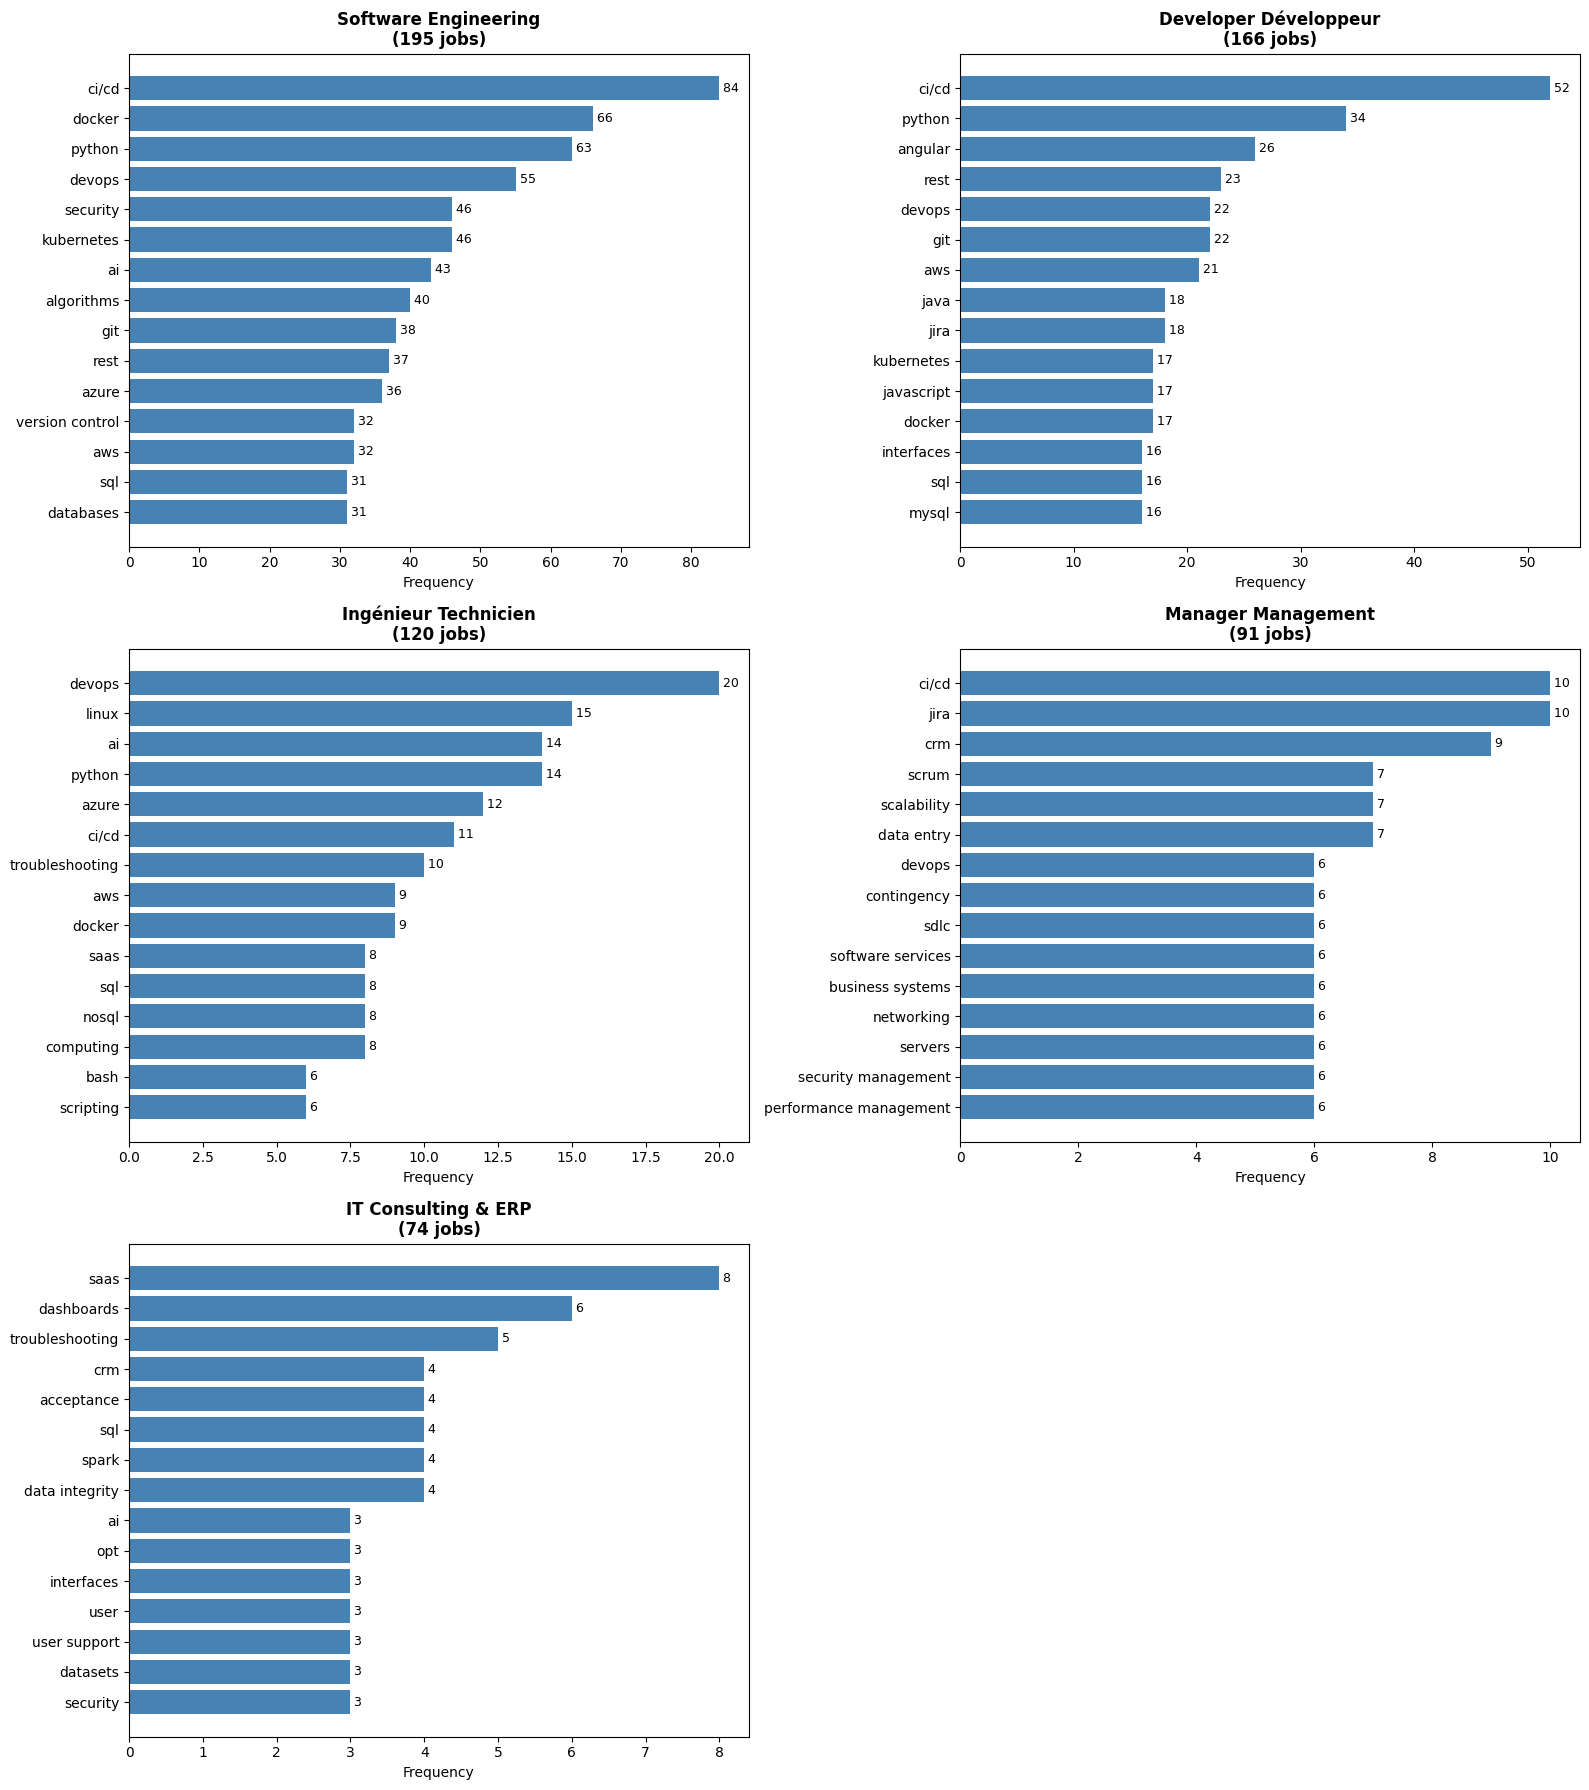

In [10]:
print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

# Get top 5 domains by job count
top_5_domains = summary_df.head(5)['domain'].tolist()

# Create subplots for top 5 domains
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, domain in enumerate(top_5_domains):
    skills = category_skills[domain][:15]  # Top 15 skills

    skill_names = [s for s, c in skills]
    skill_counts = [c for s, c in skills]

    # Plot horizontal bar chart
    axes[idx].barh(skill_names, skill_counts, color='steelblue')
    axes[idx].set_xlabel('Frequency', fontsize=10)
    axes[idx].set_title(f'{domain}\n({category_counts[domain]} jobs)',
                        fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()

    # Add count labels
    for i, (skill, count) in enumerate(zip(skill_names, skill_counts)):
        axes[idx].text(count, i, f' {count}', va='center', fontsize=9)

# Remove empty subplot
if len(top_5_domains) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('top_skills_by_domain.png', dpi=300, bbox_inches='tight')
print("✓ Saved visualization to 'top_skills_by_domain.png'")
plt.show()

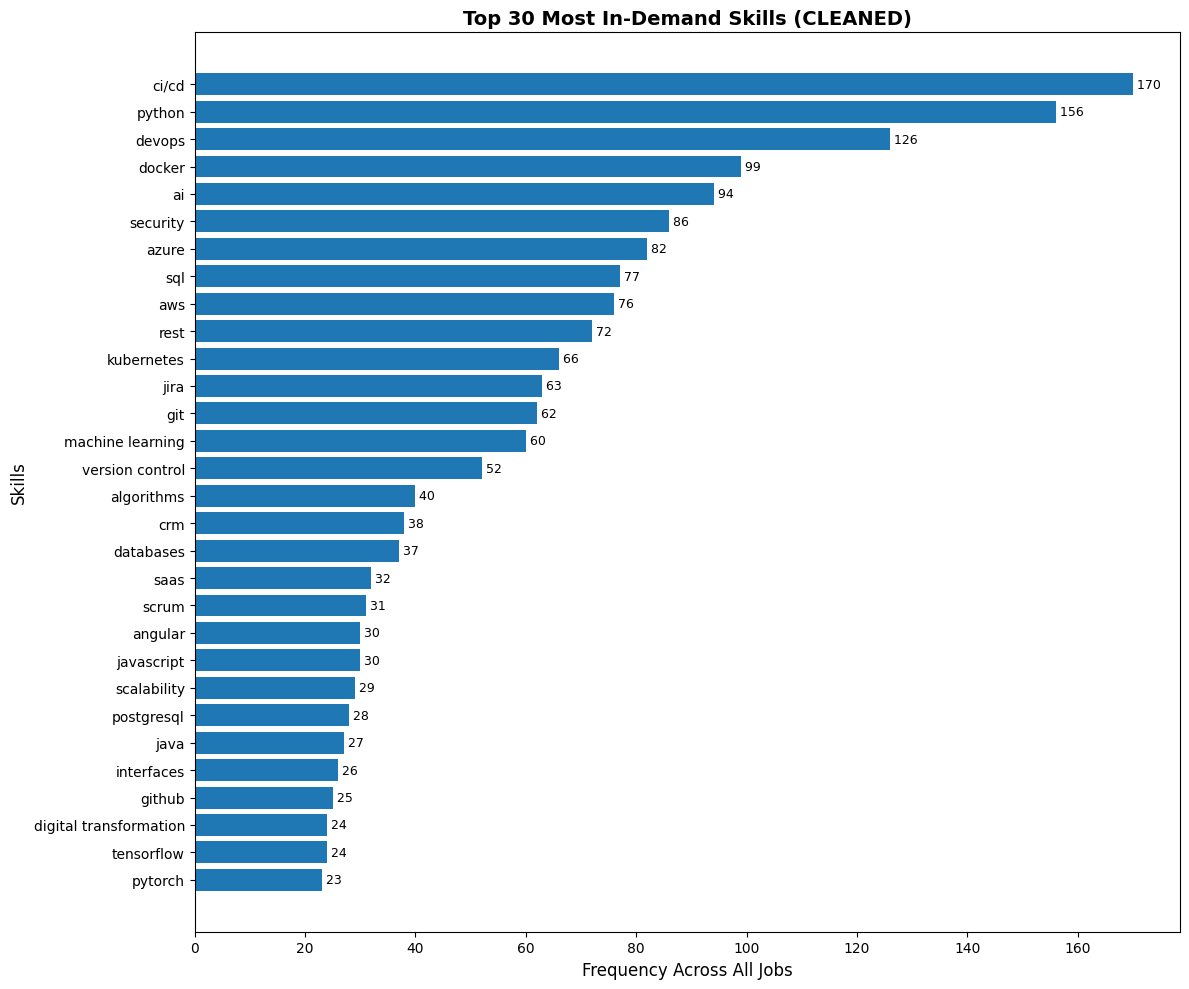

In [11]:
all_cleaned_skills = []

for category, skills in category_skills.items():
    for skill, count in skills:
        all_cleaned_skills.extend([skill] * count)
overall_skill_counts = Counter(all_cleaned_skills)
top_30_overall = overall_skill_counts.most_common(30)


plt.figure(figsize=(12, 10))

skills = [s for s, c in top_30_overall]
counts = [c for s, c in top_30_overall]

plt.barh(skills, counts)
plt.xlabel('Frequency Across All Jobs', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.title('Top 30 Most In-Demand Skills (CLEANED)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, (skill, count) in enumerate(zip(skills, counts)):
    plt.text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_skills_overall_cleaned.png', dpi=300, bbox_inches='tight')
plt.show()
